# LIBRARY

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

#  Data Wrangling

In [4]:
# LOAD KETIGA DATASET ASLI

df_sintetis = pd.read_csv("RawData/Sintetis_Data.csv")
df_gofood_raw = pd.read_csv("RawData/gofood_food_overviews.csv")
df_tokped_raw = pd.read_csv("RawData/produk_tokopedia.csv")


# WRANGLING TOKOPEDIA (Ambil 10.000 Data)

# Bersihin yang kosong dan harga ga masuk akal dulu
df_tokped = df_tokped_raw.dropna(subset=['Nama Produk', 'Harga (IDR)'])
df_tokped = df_tokped[df_tokped['Harga (IDR)'] < 5000000]
df_tokped_sample = df_tokped.sample(n=10000, random_state=42).copy()

def ngetik_tokped(teks):
    # Split teks panjang, ambil 3 sampai 4 kata 
    kata = str(teks).split()[:random.randint(3, 4)]
    nama_barang = " ".join(kata)
    
    # Tambahin awalan natural
    awalan = random.choice(["Beli ", "Checkout ", "Nyicil ", "Order ", ""])
    hasil = awalan + nama_barang
    
    return hasil.lower() if random.random() < 0.4 else hasil

# Bikin field 1 pintu: deskripsi_transaksi
df_tokped_sample['deskripsi_transaksi'] = df_tokped_sample['Nama Produk'].apply(ngetik_tokped)
df_tokped_sample['kategori'] = "Belanja"
df_tokped_sample['nominal'] = df_tokped_sample['Harga (IDR)'].astype(int)
df_tokped_sample['tipe_transaksi'] = "Pengeluaran"

# Hapus kolom asli biar ga dobel
df_tokped_sample.drop(columns=['Nama Produk', 'Harga (IDR)'], inplace=True)



# WRANGLING GOFOOD (Ambil 5.000 Data)
df_gofood = df_gofood_raw.dropna(subset=['orderItem'])
df_gofood_sample = df_gofood.sample(n=5000, random_state=42).copy()

def ngetik_gofood(teks):
    # Split berdasarkan koma (karena pesanan gofood sering gabung minuman/makanan ekstra)
    item_utama = str(teks).split(',')[0].strip()
    # Split lagi, ambil maksimal 3 kata pertama 
    kata = item_utama.split()[:random.randint(2, 3)]
    nama_makanan = " ".join(kata)
    
    # Tambahin awalan natural
    awalan = random.choice(["Gofood ", "Pesen ", "Grabfood ", "Beli ", "Jajan ", ""])
    hasil = awalan + nama_makanan
    
    return hasil.lower() if random.random() < 0.4 else hasil

# Bikin field setara menjadi deskripsi_transaksi
df_gofood_sample['deskripsi_transaksi'] = df_gofood_sample['orderItem'].apply(ngetik_gofood)
df_gofood_sample['kategori'] = "Makanan"
df_gofood_sample['tipe_transaksi'] = "Pengeluaran"
# Gofood ga punya kolom harga, kita generate acak sesuai harga makanan
df_gofood_sample['nominal'] = [random.randint(15, 150) * 1000 for _ in range(5000)] 

# Hapus kolom asli
df_gofood_sample.drop(columns=['orderItem'], inplace=True)



# GABUNGKAN SEMUANYA JADI  Data-pure
# menggunakan concat untuk mengabung semua
df_master = pd.concat([df_sintetis, df_tokped_sample, df_gofood_sample], ignore_index=True)

# Acak urutan baris biar nyampur rata
df_master = df_master.sample(frac=1).reset_index(drop=True)

# Simpan ke CSV
df_master.to_csv("Data-pure.csv", index=False)

print("WRANGLING SUKSES!")
print(f"Total Baris: {len(df_master)} data")
print("\nPreview Kolom Deskripsi Transaksi (Super Natural):")
print(df_master[['deskripsi_transaksi', 'kategori', 'nominal']].sample(15))

WRANGLING SUKSES!
Total Baris: 30468 data

Preview Kolom Deskripsi Transaksi (Super Natural):
                            deskripsi_transaksi      kategori    nominal
16980                             Bonus Project    Pendapatan  8049000.0
5011                              cicilan motor       Tagihan   585000.0
8457                                uang lembur    Pendapatan  1912000.0
26325                                 Tiket KRL  Transportasi    34000.0
21980                         beli mie iblis lv       Makanan    74000.0
7967                                  tiket mrt  Transportasi    67000.0
17991                  jbabe mini seamless hair       Belanja    30000.0
10127                 Pesen Family Time Bertiga       Makanan   132000.0
27704                 pesen light kopi kenangan       Makanan   118000.0
7610                 beli custom lanyard gelang       Belanja    25500.0
16108  Nyicil 【HARMOTID】Anting Titanium Panjang       Belanja    27999.0
7764                          

# ASSESING DATA

In [5]:
# MEngecek keseluruhan data kotor
# Load data kotor
df = pd.read_csv("Data-pure.csv")

print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

print("\n=== 4. CEK OUTLIER NOMINAL ===")
print(df['nominal'].describe().apply(lambda x: format(x, 'f')))


=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30468 entries, 0 to 30467
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              15468 non-null  object 
 1   jam                  15468 non-null  object 
 2   deskripsi_transaksi  30468 non-null  object 
 3   kategori             27158 non-null  object 
 4   nominal              28172 non-null  float64
 5   tipe_transaksi       30468 non-null  object 
 6   metode_pembayaran    15468 non-null  object 
 7   lokasi_merchant      9973 non-null   object 
 8   status_transaksi     15468 non-null  object 
 9   device_os            15468 non-null  object 
 10  catatan_user         2330 non-null   object 
 11  Nama Toko            9984 non-null   object 
 12  Lokasi Toko          9955 non-null   object 
 13  Terjual              9920 non-null   object 
 14  Jumlah Ulasan        9532 non-null   object 
 15  Rating    

In [6]:
df.head(10)

,tanggal,jam,deskripsi_transaksi,kategori,nominal,tipe_transaksi,metode_pembayaran,lokasi_merchant,status_transaksi,device_os,...,id,review,rating,createdAt,lastComment,qtyItem,orderedAt,tagsData,replayComment,timeReplayComment
0,12/04/2023,20:20,deposit kos,Tempat Tinggal,2123000.0,Pengeluaran,Mandiri,Bandung,Berhasil,Windows Web,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Beli Kanthil - Seragam,Belanja,99000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Nyicil LINESTRUE Tas Ransel Viral,Belanja,73000.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Checkout Keripik Basreng Stik,Belanja,25675.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,nyicil rak plastik hitam,Belanja,71499.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,order tumbler custom unik,Belanja,69500.0,Pengeluaran,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-05-14,06:34,BAYAR BPJS,Tagihan,925000.0,Pengeluaran,CASH,NaN,Berhasil,iOS 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,23/09/2023,21:54,bli emas antam,Investasi,4384000.0,Pengeluaran,BCA Virtual Account,Bandung,Berhasil,iOS 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2023-03-18,00:36,Langganan ChatGPT,Hiburan,375000.0,Pengeluaran,QRIS,NaN,Berhasil,Android 12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,04/05/2024,14:01,langganan icloud,Tagihan,588000.0,Pengeluaran,ovo,Surabaya,Berhasil,iOS 16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_11956\760276003.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_top28.values, y=missing_top28.index, palette='Reds_r', ax=ax2)
C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_11956\760276003.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kategori_counts.values, y=kategori_counts.index.astype(str), palette='viridis', ax=ax3)


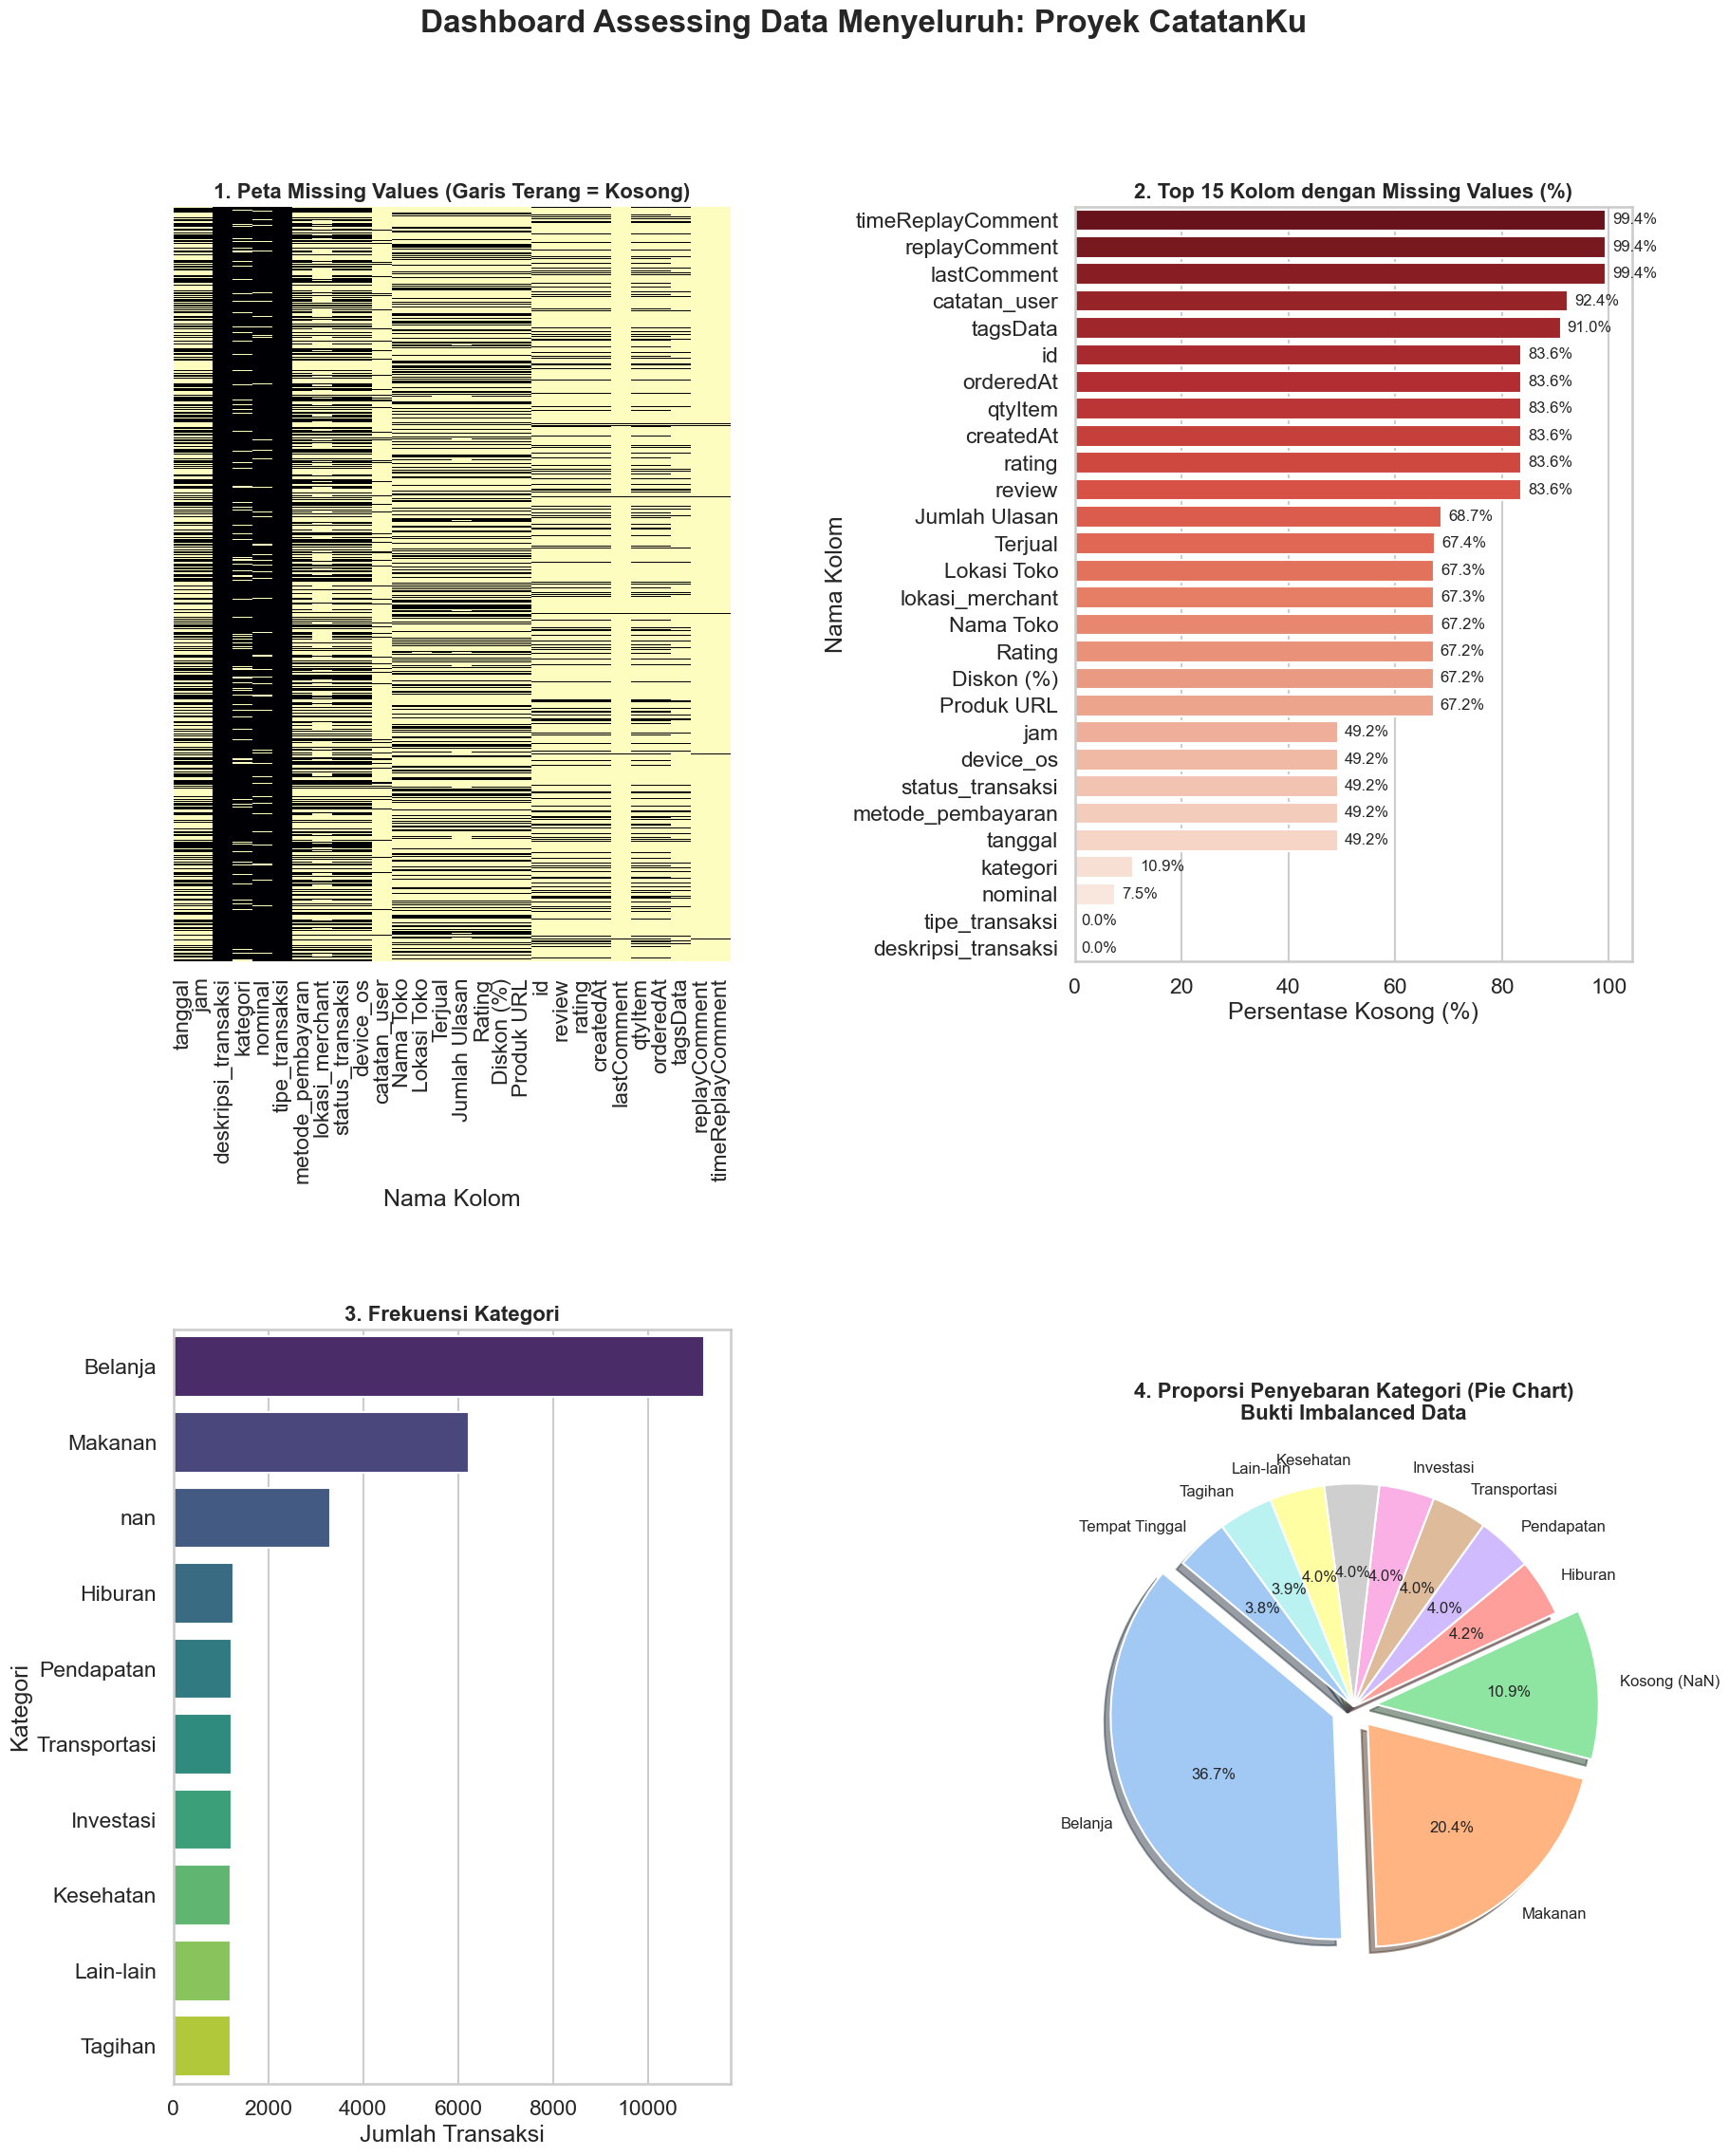

<Figure size 640x480 with 0 Axes>


INTERPRETASI KESELURUHAN (UNTUK LAPORAN ANALISIS):
Berdasarkan Dashboard Assessing Data di atas, terdapat 4 temuan kritikal pada dataset mentah:



In [7]:
# Set tema visualisasi
sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("Data-pure.csv")


fig = plt.figure(figsize=(20, 24))
fig.suptitle('Dashboard Assessing Data Menyeluruh: Proyek CatatanKu', fontsize=24, fontweight='bold', y=0.98)


# Peta Persebaran Missing Values (Heatmap)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False, ax=ax1)
ax1.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Nama Kolom')

# Persentase Data Kosong (Bar Chart)
ax2 = plt.subplot(2, 2, 2)
missing_perc = (df.isnull().sum() / len(df)) * 100
missing_top28 = missing_perc.sort_values(ascending=False).head(28)

sns.barplot(x=missing_top28.values, y=missing_top28.index, palette='Reds_r', ax=ax2)
ax2.set_title('2. Top 15 Kolom dengan Missing Values (%)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Persentase Kosong (%)')
ax2.set_ylabel('Nama Kolom')

# Tambahin teks persentase di ujung bar
for p in ax2.patches:
        ax2.annotate(f"{p.get_width():.1f}%", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=12)


# Mendeteksi Kategori Kosong

ax3 = plt.subplot(2, 2, 3)
kategori_counts = df['kategori'].value_counts(dropna=False).head(10) 
sns.barplot(x=kategori_counts.values, y=kategori_counts.index.astype(str), palette='viridis', ax=ax3)
ax3.set_title('3. Frekuensi Kategori', fontsize=16, fontweight='bold')
ax3.set_xlabel('Jumlah Transaksi')
ax3.set_ylabel('Kategori')

ax4 = plt.subplot(2, 2, 4)
# Hitung data buat pie chart 
kategori_pie_counts = df['kategori'].fillna('Kosong (NaN)').value_counts()
explode = [0.1 if i < 3 else 0 for i in range(len(kategori_pie_counts))]
colors = sns.color_palette('pastel')[0:len(kategori_pie_counts)]
# Masukin pie chart ke dalam ax4
ax4.pie(kategori_pie_counts, 
        labels=kategori_pie_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True,
        textprops={'fontsize': 12})
ax4.set_title('4. Proporsi Penyebaran Kategori (Pie Chart)\nBukti Imbalanced Data', fontsize=16, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

plt.tight_layout(pad=4.0)
plt.show()

print("""
=========================================================
INTERPRETASI KESELURUHAN (UNTUK LAPORAN ANALISIS):
=========================================================
Berdasarkan Dashboard Assessing Data di atas, terdapat 4 temuan kritikal pada dataset mentah:
""")

# Cleaning Data

In [8]:
# Ekstraksi Tanggal Bawaan Sistem (GoFood)

# Memastikan kolom 'tanggal' berformat string/object biar gampang ditimpa
df['tanggal'] = df['tanggal'].astype(str).replace('nan', np.nan)

# Ekstrak dari createdAt dan masukkan ke tanggal
if 'createdAt' in df.columns:
    # Ubah format createdAt jadi YYYY-MM-DD
    tanggal_gofood = pd.to_datetime(df['createdAt'], errors='coerce').dt.strftime('%Y-%m-%d')
    
    # Tambal baris 'tanggal' yang kosong pakai data dari 'createdAt'
    df['tanggal'] = np.where(df['tanggal'].isnull(), tanggal_gofood, df['tanggal'])
    
    print("Berhasil! Data 'createdAt' sudah dipindahkan ke kolom 'tanggal'.")
else:
    print("Kolom 'createdAt' tidak ditemukan di dataset.")

print(f"Sisa baris dengan tanggal kosong saat ini: {df['tanggal'].isnull().sum()} baris")

Berhasil! Data 'createdAt' sudah dipindahkan ke kolom 'tanggal'.
Sisa baris dengan tanggal kosong saat ini: 10001 baris


In [9]:
# FEATURE SELECTION (Membuang Kolom Tidak Terpakai)

# Definisikan kolom yang ingin di ambil
kolom_target = [
    'tanggal', 
    'deskripsi_transaksi', 
    'kategori', 
    'nominal', 
    'tipe_transaksi', 
]

# membuat dataframe baru
df_selected = df[kolom_target].copy()

print("Pembuatan Dataframe baru berhasil")
print(f"Bentuk data sekarang: {df_selected.shape[0]} baris & {df_selected.shape[1]} kolom\n")

# Tampilkan 5 data teratas untuk preview
print("\n=== PREVIEW 5 DATA TERATAS ===")
display(df_selected.head())

Pembuatan Dataframe baru berhasil
Bentuk data sekarang: 30468 baris & 5 kolom


=== PREVIEW 5 DATA TERATAS ===


,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,12/04/2023,deposit kos,Tempat Tinggal,2123000.0,Pengeluaran
1,NaN,Beli Kanthil - Seragam,Belanja,99000.0,Pengeluaran
2,NaN,Nyicil LINESTRUE Tas Ransel Viral,Belanja,73000.0,Pengeluaran
3,NaN,Checkout Keripik Basreng Stik,Belanja,25675.0,Pengeluaran
4,NaN,nyicil rak plastik hitam,Belanja,71499.0,Pengeluaran


In [10]:
# Standarisasi Teks dan Nominal
# Bikin deskripsi jadi lowercase semua biar enak dibaca NLP
df_selected['deskripsi_transaksi'] = df_selected['deskripsi_transaksi'].astype(str).str.lower()
# Pastikan nominalnya positif semua (absolute value)
df_selected['nominal'] = df_selected['nominal'].abs()

df_selected.head(10)

,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,12/04/2023,deposit kos,Tempat Tinggal,2123000.0,Pengeluaran
1,NaN,beli kanthil - seragam,Belanja,99000.0,Pengeluaran
2,NaN,nyicil linestrue tas ransel viral,Belanja,73000.0,Pengeluaran
3,NaN,checkout keripik basreng stik,Belanja,25675.0,Pengeluaran
4,NaN,nyicil rak plastik hitam,Belanja,71499.0,Pengeluaran
5,NaN,order tumbler custom unik,Belanja,69500.0,Pengeluaran
6,2023-05-14,bayar bpjs,Tagihan,925000.0,Pengeluaran
7,23/09/2023,bli emas antam,Investasi,4384000.0,Pengeluaran
8,2023-03-18,langganan chatgpt,Hiburan,375000.0,Pengeluaran
9,04/05/2024,langganan icloud,Tagihan,588000.0,Pengeluaran


In [11]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30468 entries, 0 to 30467
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              20467 non-null  object 
 1   deskripsi_transaksi  30468 non-null  object 
 2   kategori             27158 non-null  object 
 3   nominal              28172 non-null  float64
 4   tipe_transaksi       30468 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.2+ MB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                10001
deskripsi_transaksi        0
kategori                3310
nominal                 2296
tipe_transaksi             0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 519
. CEK STATISTIK DATA
            nominal
count  2.817200e+04
mean   1.089467e+07
std    1.915494e+08
min    0.000000e+00
25%    6.500000e+04
50%    1.490000e+05
75%    4.900000e+05
max    9.026000e+09


In [12]:
# Random Imputation untuk sisa tanggal kosong

df_selected['tanggal'] = pd.to_datetime(df_selected['tanggal'], errors='coerce')
# Bikin rentang waktu 2023-2024
date_pool = pd.date_range(start="2023-01-01", end="2024-12-31")

jumlah_kosong = df_selected['tanggal'].isnull().sum()
print(f"Mengisi {jumlah_kosong} baris kosong (Tokopedia) dengan tanggal acak...")

if jumlah_kosong > 0:
    random_dates = np.random.choice(date_pool, size=jumlah_kosong, replace=True)
    df_selected.loc[df_selected['tanggal'].isnull(), 'tanggal'] = random_dates

# Pastikan format akhir semuanya YYYY-MM-DD
df_selected['tanggal'] = pd.to_datetime(df_selected['tanggal'], errors='coerce').dt.strftime('%Y-%m-%d')

print("Tidak ada lagi tanggal yang bolong di dataset.")
display(df_selected[['tanggal', 'deskripsi_transaksi']].head())

Mengisi 28884 baris kosong (Tokopedia) dengan tanggal acak...
Tidak ada lagi tanggal yang bolong di dataset.


,tanggal,deskripsi_transaksi
0,2023-12-04,deposit kos
1,2024-09-18,beli kanthil - seragam
2,2024-12-18,nyicil linestrue tas ransel viral
3,2024-05-16,checkout keripik basreng stik
4,2023-11-21,nyicil rak plastik hitam


In [13]:
# menghapus data missing pada field kategori dan nominal
baris_awal = len(df_selected)
# menghapus data baris kosong 
df_selected.dropna(subset=['kategori', 'nominal'], inplace=True)
df_selected.reset_index(drop=True, inplace=True)

#Cek jumlah baris setelah di-drop
baris_akhir = len(df_selected)
total_dihapus = baris_awal - baris_akhir

print(f"Total data yang dihapus (karena kosong/invalid): {total_dihapus} baris")
print(f"Sisa baris data yang bersih dan solid: {baris_akhir} baris")

print("\n=== CEK SISA DATA KOSONG SAAT INI ===")
print(df_selected.isnull().sum())

Total data yang dihapus (karena kosong/invalid): 5103 baris
Sisa baris data yang bersih dan solid: 25365 baris

=== CEK SISA DATA KOSONG SAAT INI ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64


In [14]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\n4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25365 entries, 0 to 25364
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              25365 non-null  object 
 1   deskripsi_transaksi  25365 non-null  object 
 2   kategori             25365 non-null  object 
 3   nominal              25365 non-null  float64
 4   tipe_transaksi       25365 non-null  object 
dtypes: float64(1), object(4)
memory usage: 990.9+ KB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 29

4. CEK STATISTIK DATA
            nominal
count  2.536500e+04
mean   9.575132e+06
std    1.796174e+08
min    0.000000e+00
25%    6.000000e+04
50%    1.380000e+05
75%    4.500000e+05
max    9.026000e+09


In [15]:
# menghapus data duplikat

baris_sebelum = len(df_selected)

# menghitung ada berapa baris yang duplikat 100% (semua kolomnya sama persis)
jumlah_duplikat = df_selected.duplicated().sum()
print(f"Ditemukan {jumlah_duplikat} baris data yang duplikat.")

if jumlah_duplikat > 0:
    # menyimpan baris pertama pada data duplikat
    df_selected.drop_duplicates(keep='first', inplace=True)
    
    # Reset index biar urutan angkanya (0, 1, 2, dst) 
    df_selected.reset_index(drop=True, inplace=True)
    print("Data duplikat berhasil dibasmi!")
else:
    print("Aman! Tidak ditemukan data duplikat.")
    
baris_setelah = len(df_selected)
print(f"\nHASIL AKHIR ")
print(f"Total baris awal: {baris_sebelum}")
print(f"Total baris sekarang: {baris_setelah} baris ")

Ditemukan 29 baris data yang duplikat.
Data duplikat berhasil dibasmi!

HASIL AKHIR 
Total baris awal: 25365
Total baris sekarang: 25336 baris 


In [16]:
# Menangani anomali pada field 'nominal'
df_selected['nominal'] = pd.to_numeric(df_selected['nominal'], errors='coerce').abs()

# Cek baris sebelum filter IQR
baris_sebelum_iqr = len(df_selected)

Q1 = df_selected['nominal'].quantile(0.25)
Q3 = df_selected['nominal'].quantile(0.75)
IQR = Q3 - Q1

# membuat batas atas (Batas bawah nggak terlalu perlu karena udah di-absolut jadi positif semua)
batas_atas = Q3 + 1.5 * IQR

print(f"Statistik Nominal:")
print(f"- Q1 (Kuartil Bawah): Rp {Q1:,.0f}")
print(f"- Q3 (Kuartil Atas): Rp {Q3:,.0f}")
print(f"- Batas Atas Wajar: Rp {batas_atas:,.0f}")

# melakukan eksekusi
df_selected = df_selected[df_selected['nominal'] <= batas_atas]
# mereset index setelah eksekusi
df_selected.reset_index(drop=True, inplace=True)

# hasil
baris_setelah_iqr = len(df_selected)
outlier_dihapus = baris_sebelum_iqr - baris_setelah_iqr
print(f"\nPembersihan Outlier Berhasil!")
print(f"Total data ekstrem (outlier) yang dihapus: {outlier_dihapus} baris")
print(f"Sisa data final saat ini: {baris_setelah_iqr} baris")

Statistik Nominal:
- Q1 (Kuartil Bawah): Rp 60,000
- Q3 (Kuartil Atas): Rp 450,000
- Batas Atas Wajar: Rp 1,035,000

Pembersihan Outlier Berhasil!
Total data ekstrem (outlier) yang dihapus: 3822 baris
Sisa data final saat ini: 21514 baris


In [17]:
# Mengecek kembali data

print("=== 1. CEK INFO DASAR ===")
df_selected.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df_selected.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df_selected.duplicated().sum())

print("\n4. CEK STATISTIK DATA")
print(df_selected.describe())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21514 entries, 0 to 21513
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tanggal              21514 non-null  object 
 1   deskripsi_transaksi  21514 non-null  object 
 2   kategori             21514 non-null  object 
 3   nominal              21514 non-null  float64
 4   tipe_transaksi       21514 non-null  object 
dtypes: float64(1), object(4)
memory usage: 840.5+ KB

=== 2. CEK DATA KOSONG (Missing Values) ===
tanggal                0
deskripsi_transaksi    0
kategori               0
nominal                0
tipe_transaksi         0
dtype: int64

=== 3. CEK DATA DUPLIKAT ===
Jumlah Duplikat: 0

4. CEK STATISTIK DATA
            nominal
count  2.151400e+04
mean   1.912941e+05
std    2.148194e+05
min    0.000000e+00
25%    5.000000e+04
50%    1.120000e+05
75%    2.390000e+05
max    1.035000e+06


In [18]:
df_selected.head()

,tanggal,deskripsi_transaksi,kategori,nominal,tipe_transaksi
0,2024-09-18,beli kanthil - seragam,Belanja,99000.0,Pengeluaran
1,2024-12-18,nyicil linestrue tas ransel viral,Belanja,73000.0,Pengeluaran
2,2024-05-16,checkout keripik basreng stik,Belanja,25675.0,Pengeluaran
3,2023-11-21,nyicil rak plastik hitam,Belanja,71499.0,Pengeluaran
4,2024-10-18,order tumbler custom unik,Belanja,69500.0,Pengeluaran


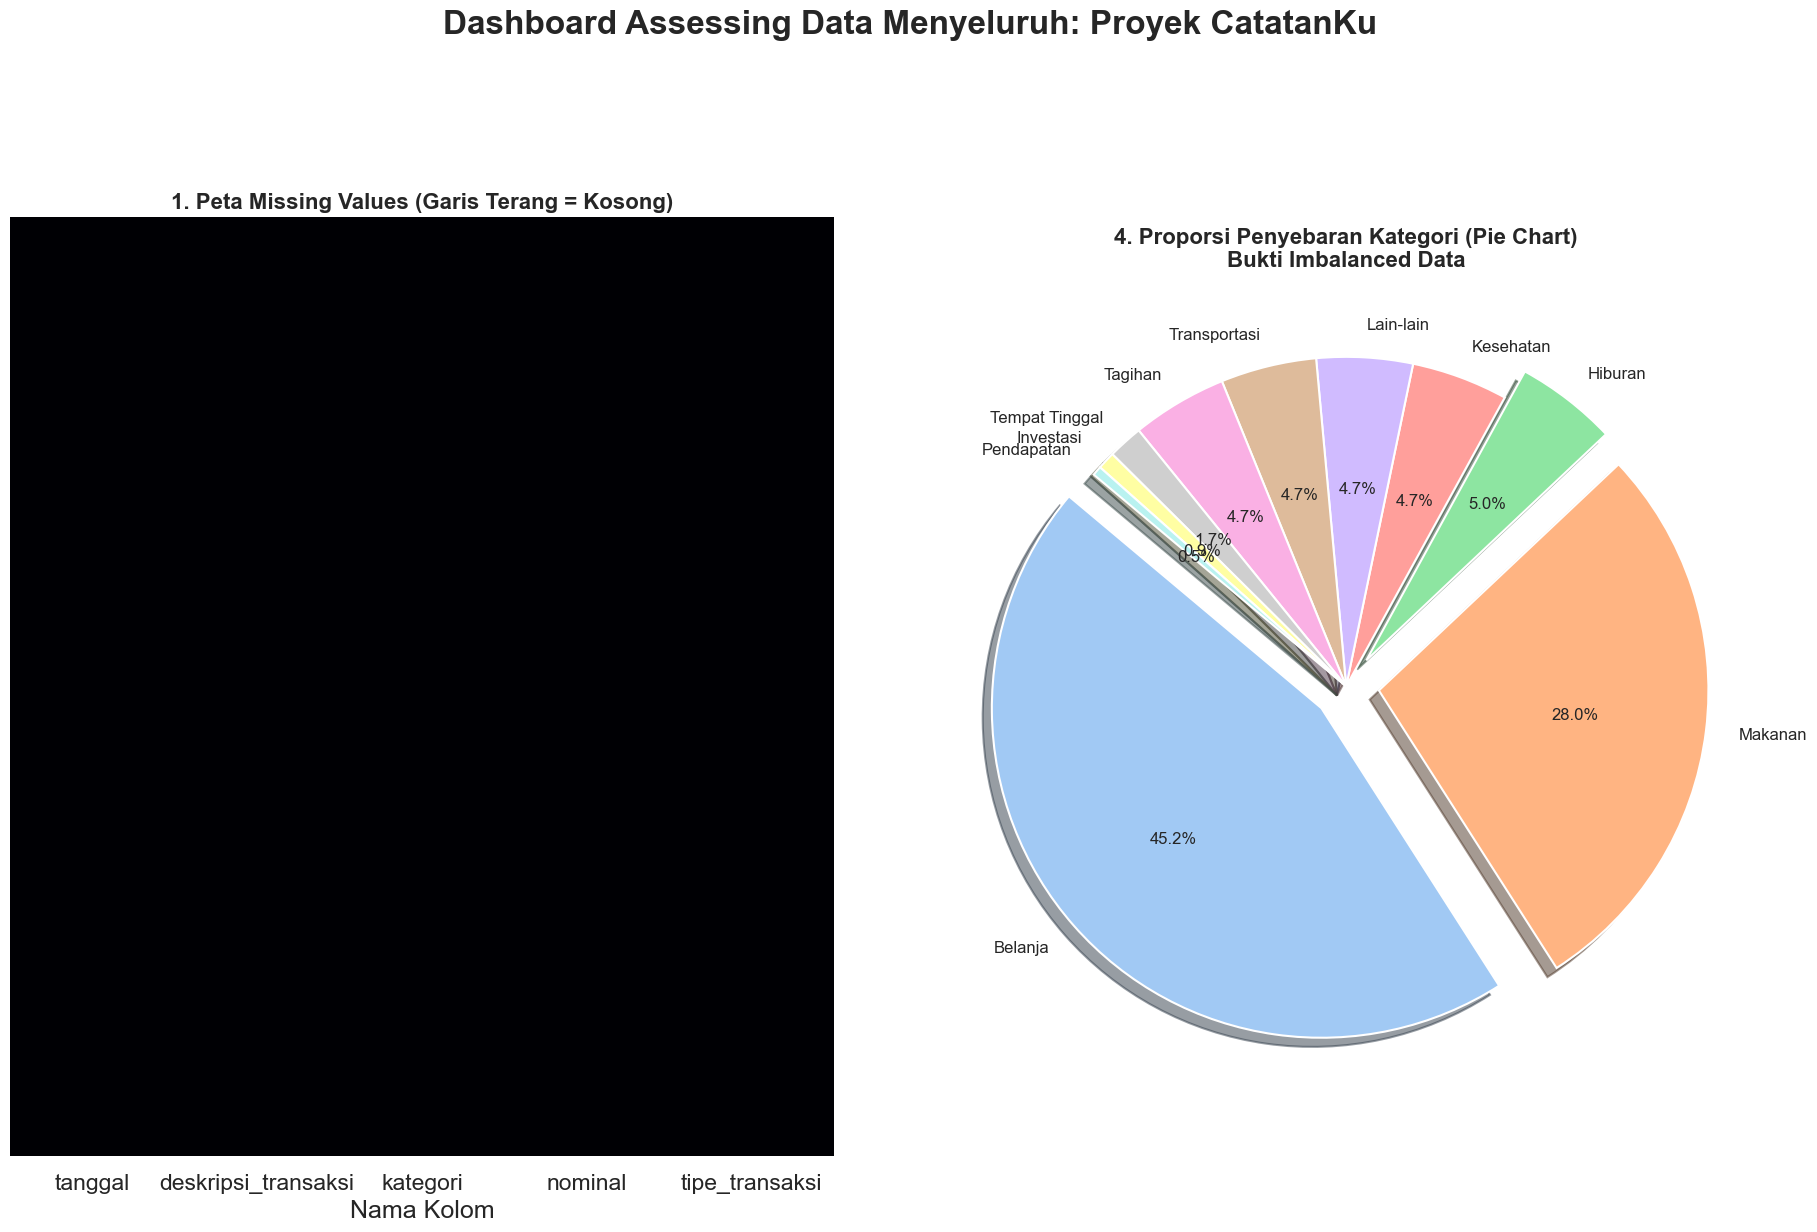

<Figure size 640x480 with 0 Axes>

In [19]:
sns.set_theme(style="whitegrid", context="talk")

df = df_selected


fig = plt.figure(figsize=(20, 24))
fig.suptitle('Dashboard Assessing Data Menyeluruh: Proyek CatatanKu', fontsize=24, fontweight='bold', y=0.98)


# Peta Persebaran Missing Values (Heatmap)
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False, ax=ax1)
ax1.set_title('1. Peta Missing Values (Garis Terang = Kosong)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Nama Kolom')

ax2 = plt.subplot(2, 2, 2)
# Hitung data buat pie chart (ubah NaN jadi teks biar terbaca di chart)
kategori_pie_counts = df['kategori'].fillna('Kosong (NaN)').value_counts()
explode = [0.1 if i < 3 else 0 for i in range(len(kategori_pie_counts))]
colors = sns.color_palette('pastel')[0:len(kategori_pie_counts)]
# Masukin pie chart ke dalam ax4
ax2.pie(kategori_pie_counts, 
        labels=kategori_pie_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors, 
        explode=explode, 
        shadow=True,
        textprops={'fontsize': 12})
ax2.set_title('4. Proporsi Penyebaran Kategori (Pie Chart)\nBukti Imbalanced Data', fontsize=16, fontweight='bold')

plt.tight_layout(pad=4.0)
plt.show()

plt.tight_layout(pad=4.0)
plt.show()


In [20]:
df_selected.to_csv("Data-clean.csv", index=False)